## Scenario

Patient comes →
Check BMI →
Route based on condition:

If BMI is high → Go to Diet Plan Node

If BMI is normal → Go to Maintain Plan Node

In [1]:
#1: Define State
from typing import TypedDict

class HealthState(TypedDict):
    weight: float
    height: float
    bmi: float
    plan: str

In [2]:
#2: Node 1 → Calculate BMI

def calculate_bmi(state: HealthState) -> HealthState:
    state["bmi"] = state["weight"] / (state["height"] ** 2)
    return state

In [3]:
#3: Decision Function

def decide_plan(state: HealthState) -> str:
    if state["bmi"] >= 25:
        return "diet_node"
    else:
        return "maintain_node"

In [4]:
#4: Node 2 → Diet Plan

def diet_plan(state: HealthState) -> HealthState:
    state["plan"] = "Low calorie diet + Exercise"
    return state

In [5]:
#5: Node 3 → Maintain Plan

def maintain_plan(state: HealthState) -> HealthState:
    state["plan"] = "Maintain current lifestyle"
    return state

In [6]:
#6: Build Graph
from langgraph.graph import StateGraph, START, END

builder = StateGraph(HealthState)

builder.add_node("bmi_node", calculate_bmi)
builder.add_node("diet_node", diet_plan)
builder.add_node("maintain_node", maintain_plan)

# Linear start
builder.add_edge(START, "bmi_node")

# Conditional routing
builder.add_conditional_edges(
    "bmi_node",
    decide_plan,
    {
        "diet_node": "diet_node",
        "maintain_node": "maintain_node"
    }
)

# End paths
builder.add_edge("diet_node", END)
builder.add_edge("maintain_node", END)

graph = builder.compile()

c:\Users\User\Desktop\vccodepy\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


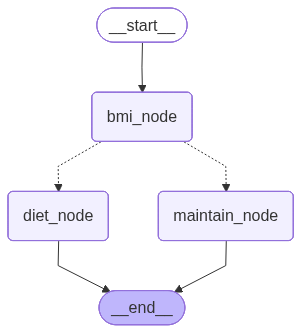

In [7]:
#7: Visualize Graph
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
#8: Run Example

result = graph.invoke({
    "weight": 85,   # try high weight
    "height": 1.7
})

print(result)

{'weight': 85, 'height': 1.7, 'bmi': 29.411764705882355, 'plan': 'Low calorie diet + Exercise'}
